# 07. Statistical Tests
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook performs all statistical analyses reported in the paper:

1. **Wilcoxon signed-rank test** — pairwise significance between GA-G-CTGAN and each baseline
2. **Friedman test** — overall ranking difference across all methods
3. **Nemenyi post-hoc test** — multiple comparison correction with Critical Difference (CD) diagram

Significance level: α = 0.05

> **Scope:** Statistical tests are performed on the **6 GA-G-CTGAN applicable datasets**
> (`credit_default`, `pima_diabetes`, `ibm_attrition`, `yeast_me2`, `wine_quality`, `ecoli`)
> to ensure a fair comparison where all methods are evaluated on the same datasets.


## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations

warnings.filterwarnings("ignore")

RESULTS_DIR = "./results"

# Statistical tests use ALL 11 datasets
# GA-G-CTGAN is included only where applicable (6 datasets)
# For methods without GA-G-CTGAN, NaN is handled automatically

STAT_DATASETS = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "CTGAN", "TVAE", "G-CTGAN", "GA-G-CTGAN"
]

ALPHA = 0.05

print(f"Datasets for statistical tests : {STAT_DATASETS}")
print(f"Methods                        : {METHOD_ORDER}")
print(f"Significance level             : α = {ALPHA}")


Datasets for statistical tests : ['credit_default', 'fraud_detection', 'pima_diabetes', 'ibm_attrition', 'yeast_me2', 'mammography', 'abalone_19', 'wine_quality', 'ecoli', 'pageblocks', 'protein_homo']
Methods                        : ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'GA-G-CTGAN']
Significance level             : α = 0.05


## 1. Load & Prepare Data

In [2]:
dfs = []

for fname in ["02_baselines_results.csv",
              "04_gctgan_results.csv",
              "05_ga_gctgan_results.csv"]:
    path = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(path):
        dfs.append(pd.read_csv(path))
    else:
        print(f"Not found: {fname}")

combined = pd.concat(dfs, ignore_index=True)

# Filter: applicable datasets and methods only
combined = combined[
    combined["dataset"].isin(STAT_DATASETS) &
    combined["oversampling"].isin(METHOD_ORDER)
]

print(f"Combined rows : {len(combined)}")
print(f"Methods found : {combined['oversampling'].unique().tolist()}")
print(f"Classifiers   : {combined['classifier'].unique().tolist()}")


Combined rows : 231
Methods found : ['SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'GA-G-CTGAN']
Classifiers   : ['RF', 'LGBM', 'MLP']


## 2. Build AUC Matrix for Statistical Tests

In [3]:
def build_auc_matrix(clf_name):
    sub = combined[combined["classifier"] == clf_name]
    pivot = sub.pivot_table(
        index="dataset", columns="oversampling",
        values="AUC", aggfunc="mean"
    )
    pivot = pivot.reindex(
        index=STAT_DATASETS,
        columns=[m for m in METHOD_ORDER if m in pivot.columns]
    )
    return pivot  # NaN 제거 안 함 — 각 섹션에서 처리

# Preview
for clf in ["RF", "LGBM", "MLP"]:
    tbl = build_auc_matrix(clf)
    print(f"\n── {clf} AUC Matrix ──")
    print(tbl.round(4).to_string())



── RF AUC Matrix ──
oversampling      SMOTE  ADASYN  G-SMOTE   CTGAN    TVAE  G-CTGAN  GA-G-CTGAN
dataset                                                                      
credit_default   0.7733  0.7684   0.7517  0.7655  0.7632   0.7636      0.7650
fraud_detection  0.9763  0.9753   0.9756  0.9639  0.9551   0.9618      0.9751
pima_diabetes    0.8426  0.8442   0.8355  0.8048  0.8349   0.8002      0.8187
ibm_attrition    0.7797  0.7888   0.7888  0.7665  0.7780   0.7754      0.7650
yeast_me2        0.9027  0.8919   0.9058  0.9225  0.9145   0.9183      0.9318
mammography      0.9700  0.9648   0.9689  0.9533  0.9610   0.9542      0.9562
abalone_19       0.8096  0.8259   0.8412  0.7520  0.7580   0.7936      0.8211
wine_quality     0.8467  0.8404   0.8549  0.8154  0.8148   0.8040      0.8419
ecoli            0.9566  0.9545   0.9566  0.9848  0.9707   0.9798      0.9697
pageblocks       0.9971  0.9976   0.9972  0.9962  0.9968   0.9961      0.9976
protein_homo     0.9951  0.9937   0.9952  0

## 3. Friedman Test

In [4]:
friedman_results = {}

print("Friedman Test Results")
print("=" * 60)
print(f"H0: No significant difference in AUC rankings across methods")
print(f"Significance level: α = {ALPHA}")
print()

for clf in ["RF", "LGBM", "MLP"]:
    tbl = build_auc_matrix(clf).dropna(axis=0)  # axis=1 → axis=0

    # Friedman test requires complete data (no NaN)
    data_arrays = [tbl[col].values for col in tbl.columns]

    stat, p_value = stats.friedmanchisquare(*data_arrays)
    reject = p_value < ALPHA

    friedman_results[clf] = {
        "statistic": stat,
        "p_value"  : p_value,
        "reject"   : reject,
        "methods"  : tbl.columns.tolist(),
        "n_datasets": len(tbl),
    }

    print(f"Classifier: {clf}")
    print(f"  χ² = {stat:.4f},  p = {p_value:.4f},  "
          f"{'✓ Reject H0 (significant)' if reject else '✗ Fail to reject H0'}")
    print(f"  n_datasets={len(tbl)},  n_methods={len(tbl.columns)}")
    print()


Friedman Test Results
H0: No significant difference in AUC rankings across methods
Significance level: α = 0.05

Classifier: RF
  χ² = 16.3165,  p = 0.0122,  ✓ Reject H0 (significant)
  n_datasets=11,  n_methods=7

Classifier: LGBM
  χ² = 6.2463,  p = 0.3962,  ✗ Fail to reject H0
  n_datasets=11,  n_methods=7

Classifier: MLP
  χ² = 6.5065,  p = 0.3689,  ✗ Fail to reject H0
  n_datasets=11,  n_methods=7



## 4. Wilcoxon Signed-Rank Test (GA-G-CTGAN vs each baseline)

In [5]:
wilcoxon_results = {}

print("Wilcoxon Signed-Rank Test")
print("=" * 60)
print(f"H0: No significant difference between GA-G-CTGAN and baseline")
print(f"Significance level: α = {ALPHA}")
print()

PROPOSED = "GA-G-CTGAN"

for clf in ["RF", "LGBM", "MLP"]:
    tbl = build_auc_matrix(clf)

    if PROPOSED not in tbl.columns:
        print(f"[{clf}] GA-G-CTGAN not found, skipping.")
        continue

    proposed_auc = tbl[PROPOSED].values
    wilcoxon_results[clf] = {}

    print(f"── Classifier: {clf} ──")
    print(f"{'Baseline':<15} {'W-stat':>8}  {'p-value':>8}  {'Sig':>5}  "
          f"{'Mean Δ':>8}  {'Wins':>5}")
    print("-" * 60)

    baselines = [m for m in tbl.columns if m != PROPOSED]
    for baseline in baselines:
        baseline_auc = tbl[baseline].values

        # Remove NaN pairs
        mask = ~(np.isnan(proposed_auc) | np.isnan(baseline_auc))
        if mask.sum() < 3:
            continue

        p_auc = proposed_auc[mask]
        b_auc = baseline_auc[mask]

        try:
            w_stat, p_val = stats.wilcoxon(p_auc, b_auc, alternative="two-sided")
        except Exception:
            w_stat, p_val = np.nan, np.nan

        sig       = "✓" if p_val < ALPHA else " "
        mean_diff = np.mean(p_auc - b_auc)
        wins      = int(np.sum(p_auc > b_auc))

        wilcoxon_results[clf][baseline] = {
            "W"       : w_stat,
            "p_value" : p_val,
            "sig"     : p_val < ALPHA,
            "mean_diff": mean_diff,
            "wins"    : wins,
            "n"       : int(mask.sum()),
        }

        print(f"  {baseline:<13} {w_stat:>8.2f}  {p_val:>8.4f}  {sig:>5}  "
              f"{mean_diff:>+8.4f}  {wins:>3}/{mask.sum()}")
    print()


Wilcoxon Signed-Rank Test
H0: No significant difference between GA-G-CTGAN and baseline
Significance level: α = 0.05

── Classifier: RF ──
Baseline          W-stat   p-value    Sig    Mean Δ   Wins
------------------------------------------------------------
  SMOTE            25.00    0.5195          -0.0015    4/11
  ADASYN           19.00    0.3863          -0.0011    3/11
  G-SMOTE          25.00    0.5195          -0.0035    4/11
  CTGAN            12.00    0.0674          +0.0124    8/11
  TVAE             19.00    0.2402          +0.0095    7/11
  G-CTGAN           9.00    0.0322      ✓   +0.0103    9/11

── Classifier: LGBM ──
Baseline          W-stat   p-value    Sig    Mean Δ   Wins
------------------------------------------------------------
  SMOTE            27.00    0.6377          -0.0016    4/11
  ADASYN           26.00    0.5771          +0.0016    7/11
  G-SMOTE          27.00    0.6377          -0.0032    6/11
  CTGAN            12.00    0.0674          +0.0047    9/

## 5. Nemenyi Post-hoc Test & CD Diagram

── RF Average Ranks ──
  SMOTE           2.8636
  G-SMOTE         2.9091
  ADASYN          3.1818
  GA-G-CTGAN      3.7727
  TVAE            4.9091
  CTGAN           5.0000
  G-CTGAN         5.3636

── LGBM Average Ranks ──
  SMOTE           3.1364
  GA-G-CTGAN      3.2727
  G-SMOTE         3.9091
  G-CTGAN         3.9545
  ADASYN          4.1364
  TVAE            4.6364
  CTGAN           4.9545

── MLP Average Ranks ──
  G-CTGAN         2.9091
  CTGAN           3.4545
  GA-G-CTGAN      3.6364
  SMOTE           4.1818
  ADASYN          4.5455
  G-SMOTE         4.6364
  TVAE            4.6364



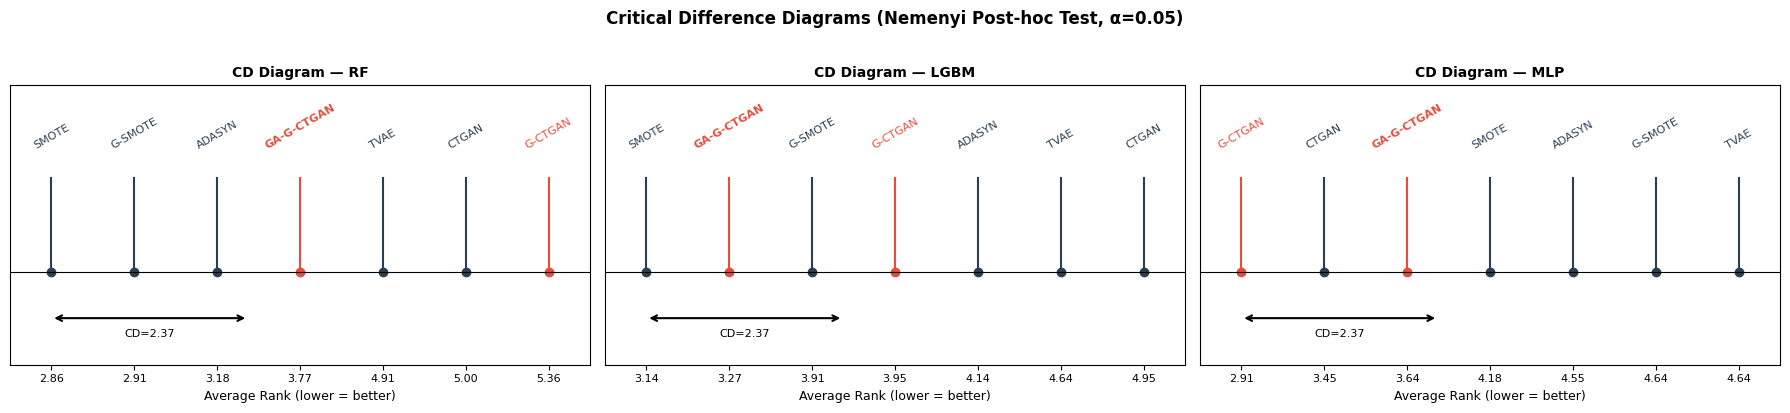

Figure saved → ./results\07_cd_diagram.png


In [6]:
# Install scikit-posthocs if needed
try:
    import scikit_posthocs as sp
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install",
                    "scikit-posthocs", "-q", "--break-system-packages"])
    import scikit_posthocs as sp

def draw_cd_diagram(avg_ranks, cd, title, ax):
    """Draw Critical Difference diagram."""
    methods = list(avg_ranks.keys())
    ranks   = list(avg_ranks.values())

    sorted_pairs = sorted(zip(ranks, methods))
    sorted_ranks = [r for r, m in sorted_pairs]
    sorted_methods = [m for r, m in sorted_pairs]

    n_methods = len(methods)
    ax.set_xlim(0.5, n_methods + 0.5)
    ax.set_ylim(-1, 2)
    ax.set_yticks([])
    ax.set_xticks(range(1, n_methods + 1))
    ax.set_xticklabels([f"{r:.2f}" for r in sorted_ranks], fontsize=8)
    ax.set_xlabel("Average Rank (lower = better)", fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

    # Draw method labels
    for i, (r, m) in enumerate(sorted_pairs):
        x = i + 1
        color = "#E74C3C" if m in ["GA-G-CTGAN", "G-CTGAN"] else "#2C3E50"
        ax.text(x, 1.3, m, ha="center", va="bottom", fontsize=8,
                fontweight="bold" if m == "GA-G-CTGAN" else "normal",
                color=color, rotation=30)
        ax.plot([x, x], [0, 1], color=color, linewidth=1.5)
        ax.plot(x, 0, "o", color=color, markersize=6)

    # Draw CD bar
    ax.annotate("", xy=(1 + cd, -0.5), xytext=(1, -0.5),
                arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
    ax.text(1 + cd / 2, -0.7, f"CD={cd:.2f}", ha="center", fontsize=8)
    ax.axhline(0, color="black", linewidth=0.8)

nemenyi_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, clf in zip(axes, ["RF", "LGBM", "MLP"]):
    tbl = build_auc_matrix(clf).dropna(axis=1)

    # Nemenyi test
    try:
        ph = sp.posthoc_nemenyi_friedman(tbl.values)
        ph.index   = tbl.columns
        ph.columns = tbl.columns
        nemenyi_results[clf] = ph

        # Average ranks
        ranks_df   = tbl.rank(axis=1, ascending=False)
        avg_ranks  = ranks_df.mean().to_dict()

        # CD formula (Demsar, 2006)
        k = len(tbl.columns)
        n = len(tbl)
        q_alpha = 2.576  # α=0.05, two-tailed
        cd = q_alpha * np.sqrt(k * (k + 1) / (6 * n))

        draw_cd_diagram(avg_ranks, cd, f"CD Diagram — {clf}", ax)

        print(f"── {clf} Average Ranks ──")
        for m, r in sorted(avg_ranks.items(), key=lambda x: x[1]):
            print(f"  {m:<15} {r:.4f}")
        print()

    except Exception as e:
        print(f"[{clf}] Nemenyi test failed: {e}")
        ax.set_title(f"{clf} — failed")

plt.suptitle("Critical Difference Diagrams (Nemenyi Post-hoc Test, α=0.05)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "07_cd_diagram.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")


## 6. Nemenyi p-value Tables

In [7]:
print("Nemenyi Post-hoc p-value Tables")
print("(values < 0.05 indicate significant difference)")
print()

for clf in ["RF", "LGBM", "MLP"]:
    if clf not in nemenyi_results:
        continue
    ph = nemenyi_results[clf]
    print(f"── Classifier: {clf} ──")
    print(ph.round(4).to_string())
    print()

    # Highlight GA-G-CTGAN row
    if "GA-G-CTGAN" in ph.index:
        row = ph.loc["GA-G-CTGAN"]
        sig_pairs = row[row < ALPHA].index.tolist()
        if "GA-G-CTGAN" in sig_pairs:
            sig_pairs.remove("GA-G-CTGAN")
        print(f"  GA-G-CTGAN significantly different from: {sig_pairs}")
    print()


Nemenyi Post-hoc p-value Tables
(values < 0.05 indicate significant difference)

── Classifier: RF ──
oversampling   SMOTE  ADASYN  G-SMOTE   CTGAN    TVAE  G-CTGAN  GA-G-CTGAN
oversampling                                                              
SMOTE         1.0000  0.9999   1.0000  0.2346  0.2842   0.0947      0.9570
ADASYN        0.9999  1.0000   0.9999  0.4314  0.4969   0.2120      0.9954
G-SMOTE       1.0000  0.9999   1.0000  0.2587  0.3112   0.1073      0.9665
CTGAN         0.2346  0.4314   0.2587  1.0000  1.0000   0.9997      0.8369
TVAE          0.2842  0.4969   0.3112  1.0000  1.0000   0.9989      0.8812
G-CTGAN       0.0947  0.2120   0.1073  0.9997  0.9989   1.0000      0.5977
GA-G-CTGAN    0.9570  0.9954   0.9665  0.8369  0.8812   0.5977      1.0000

  GA-G-CTGAN significantly different from: []

── Classifier: LGBM ──
oversampling   SMOTE  ADASYN  G-SMOTE   CTGAN    TVAE  G-CTGAN  GA-G-CTGAN
oversampling                                                              
SM

## 7. Summary Table for Paper

In [8]:
print("Statistical Test Summary (for paper)")
print("=" * 70)
print()
print("Friedman Test:")
for clf, res in friedman_results.items():
    print(f"  {clf}: χ²={res['statistic']:.3f}, p={res['p_value']:.4f}, "
          f"{'significant' if res['reject'] else 'not significant'}")

print()
print("Wilcoxon Test — GA-G-CTGAN vs baselines (RF):")
if "RF" in wilcoxon_results:
    for baseline, res in wilcoxon_results["RF"].items():
        sig_mark = "(*)" if res["sig"] else "   "
        print(f"  vs {baseline:<13} {sig_mark}  "
              f"W={res['W']:.2f}, p={res['p_value']:.4f}, "
              f"Δ={res['mean_diff']:+.4f}, wins={res['wins']}/{res['n']}")

# Save all results
summary_rows = []
for clf in ["RF", "LGBM", "MLP"]:
    if clf not in wilcoxon_results:
        continue
    for baseline, res in wilcoxon_results[clf].items():
        summary_rows.append({
            "classifier" : clf,
            "method_A"   : "GA-G-CTGAN",
            "method_B"   : baseline,
            "W_stat"     : res["W"],
            "p_value"    : res["p_value"],
            "significant": res["sig"],
            "mean_delta" : res["mean_diff"],
            "wins"       : res["wins"],
            "n_datasets" : res["n"],
        })

summary_df = pd.DataFrame(summary_rows)
save_path  = os.path.join(RESULTS_DIR, "07_wilcoxon_summary.csv")
summary_df.to_csv(save_path, index=False)
print(f"\nWilcoxon summary saved → {save_path}")


Statistical Test Summary (for paper)

Friedman Test:
  RF: χ²=16.316, p=0.0122, significant
  LGBM: χ²=6.246, p=0.3962, not significant
  MLP: χ²=6.506, p=0.3689, not significant

Wilcoxon Test — GA-G-CTGAN vs baselines (RF):
  vs SMOTE              W=25.00, p=0.5195, Δ=-0.0015, wins=4/11
  vs ADASYN             W=19.00, p=0.3863, Δ=-0.0011, wins=3/11
  vs G-SMOTE            W=25.00, p=0.5195, Δ=-0.0035, wins=4/11
  vs CTGAN              W=12.00, p=0.0674, Δ=+0.0124, wins=8/11
  vs TVAE               W=19.00, p=0.2402, Δ=+0.0095, wins=7/11
  vs G-CTGAN       (*)  W=9.00, p=0.0322, Δ=+0.0103, wins=9/11

Wilcoxon summary saved → ./results\07_wilcoxon_summary.csv


            meanrank      mean       std ci_lower ci_upper effect_size  \
G-CTGAN     5.363636  0.883627  0.094704      NaN      NaN         0.0   
CTGAN       5.000000  0.881482  0.099618      NaN      NaN    0.022074   
TVAE        4.909091  0.884427  0.095185      NaN      NaN   -0.008426   
GA-G-CTGAN  3.772727  0.893909  0.092037      NaN      NaN   -0.110107   
ADASYN      3.181818  0.895045  0.085312      NaN      NaN   -0.126685   
G-SMOTE     2.909091  0.897400  0.087262      NaN      NaN   -0.151251   
SMOTE       2.863636  0.895427  0.087754      NaN      NaN   -0.129251   

             magnitude effect_size_above magnitude_above  
G-CTGAN     negligible               0.0      negligible  
CTGAN       negligible          0.022074      negligible  
TVAE        negligible         -0.030232      negligible  
GA-G-CTGAN  negligible         -0.101275      negligible  
ADASYN      negligible         -0.012806      negligible  
G-SMOTE     negligible         -0.027286      negligi

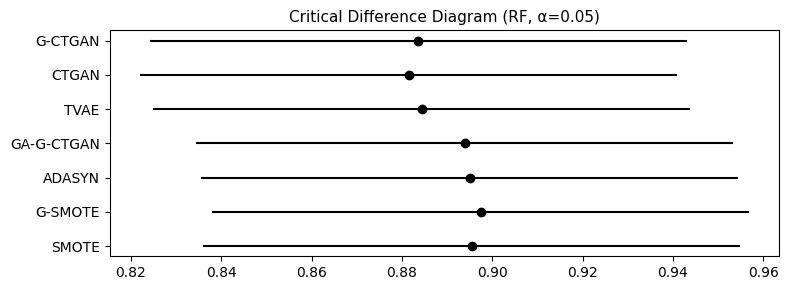

CD diagram saved → results/cd_diagram.pdf / .png
RankResult(rankdf=
            meanrank      mean       std  ci_lower  ci_upper effect_size  \
G-CTGAN     5.363636  0.883627  0.094704  0.824199  0.943055         0.0   
CTGAN       5.000000  0.881482  0.099618  0.822054   0.94091    0.022074   
TVAE        4.909091  0.884427  0.095185  0.824999  0.943855   -0.008426   
GA-G-CTGAN  3.772727  0.893909  0.092037  0.834481  0.953337   -0.110107   
ADASYN      3.181818  0.895045  0.085312  0.835617  0.954473   -0.126685   
G-SMOTE     2.909091  0.897400  0.087262  0.837972  0.956828   -0.151251   
SMOTE       2.863636  0.895427  0.087754  0.835999  0.954855   -0.129251   

             magnitude effect_size_above magnitude_above  
G-CTGAN     negligible               0.0      negligible  
CTGAN       negligible          0.022074      negligible  
TVAE        negligible         -0.030232      negligible  
GA-G-CTGAN  negligible         -0.101275      negligible  
ADASYN      negligible      

In [2]:
# ── CD Diagram (RF 기준) ──────────────────────────────────────
# pip install autorank matplotlib
import autorank
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42   # Type 3 폰트 방지 (논문 제출용)

# RF AUC 매트릭스 (dataset × method)
rf_data = {
    "SMOTE":      [0.7733,0.9763,0.8426,0.7797,0.9027,0.9700,0.8096,0.8467,0.9566,0.9971,0.9951],
    "ADASYN":     [0.7684,0.9753,0.8442,0.7888,0.8919,0.9648,0.8259,0.8404,0.9545,0.9976,0.9937],
    "G-SMOTE":    [0.7517,0.9756,0.8355,0.7888,0.9058,0.9689,0.8412,0.8549,0.9566,0.9972,0.9952],
    "CTGAN":      [0.7655,0.9639,0.8048,0.7665,0.9225,0.9533,0.7520,0.8154,0.9848,0.9962,0.9714],
    "TVAE":       [0.7632,0.9551,0.8349,0.7780,0.9145,0.9610,0.7580,0.8148,0.9707,0.9968,0.9817],
    "G-CTGAN":    [0.7636,0.9618,0.8002,0.7754,0.9183,0.9542,0.7936,0.8040,0.9798,0.9961,0.9729],
    "GA-G-CTGAN": [0.7650,0.9751,0.8187,0.7650,0.9318,0.9562,0.8211,0.8419,0.9697,0.9976,0.9909],
}

datasets = [
    "credit_default","fraud_detection","pima_diabetes","ibm_attrition",
    "yeast_me2","mammography","abalone_19","wine_quality",
    "ecoli","pageblocks","protein_homo"
]

df_rf = pd.DataFrame(rf_data, index=datasets)

# autorank 분석
result = autorank.autorank(df_rf, alpha=0.05, verbose=False)

# CD diagram 저장
fig, ax = plt.subplots(figsize=(8, 3))
autorank.plot_stats(result, ax=ax)
ax.set_title("Critical Difference Diagram (RF, α=0.05)", fontsize=11)
plt.tight_layout()

# PDF + PNG 둘 다 저장
fig.savefig("results/cd_diagram.pdf", bbox_inches="tight")
fig.savefig("results/cd_diagram.png", dpi=300, bbox_inches="tight")
plt.show()
print("CD diagram saved → results/cd_diagram.pdf / .png")

# autorank 요약 출력
print(result)